In [1]:
import k_fail_GPS
import k_fail_MBTR
import BB_wrapper
import k_fail_prediction

import torch

/Users/karim/projects/k-sPSS/.venv/lib/python3.11/site-packages/pycutest/__init__.py:26: RuntimeWarning: the PYCUTEST_CACHE environment variable is not set; current folder will be used for caching.
  warnings.warn("the PYCUTEST_CACHE environment variable is not set; current folder will be used for caching.", RuntimeWarning)


# Test Set

In [2]:
cap_n_problems = 24

cutest_wrapper = BB_wrapper.BB_cutest_collection(write_to_file="hyperparam_tuning/cutest_problem_selection_hyperparam_tuning.txt", max_dim=100, cap_n_problems=cap_n_problems,
                problem_names=[
    "SISSER",
    # "CHWIRUT2LS",
    "DENSCHNB", "GBRAINLS",
    # "MGH10LS",
    "QING",
    # "BOX3",
    "DENSCHNC",
    # "LANCZOS3LS",
    # "GAUSS1LS",
    "MGH09LS",
    # "LANCZOS1LS",
    # "BA-L1LS",
    # "GAUSS3LS",
    "DENSCHNA",
    # "NELSONLS",
    "LUKSAN21LS", "VANDANMSLS",
    "SENSORS",
    # "DENSCHND",
    # "DANWOODLS",
    "CUBE", "MUONSINELS",
    # "DENSCHNE",
    "DMN15333LS", "DIAMON3DLS",
    # "EXPFIT",
    "HELIX", "LSC2LS", "KOWOSB",
    "S308", "DANIWOODLS", "DENSCHNF", "LRIJCNN1", "YFITU",
    # "GAUSS2LS",
    # "CHWIRUT1LS",
    "COOLHANSLS", "HAHN1LS",
    # "HIMMELBB",
                ])
# problem idx: 6 gets <= -1e20
# problem idx: 8 gets <= -1e20
# problem idx: 11 gets <= -1e20
# problem idx: 20 gets <= -1e20

# BOX3
# LANCZOS3LS
# LANCZOS1LS
# DANWOODLS
# CHWIRUT2LS
# MGH10LS
# GAUSS1LS
# BA-L1LS
# GAUSS3LS
# NELSONLS
# DENSCHND
# DENSCHNE
# EXPFIT a
# GAUSS2LS
# CHWIRUT1LS
# HIMMELBB

loading problems...
0/24
20/24
loaded 24 problems


In [3]:
import pycutest
import numpy as np

p = pycutest.import_problem("BOX3")

print(p.obj(np.array([62.07203904539347, -2132.5309031791985, 170.89948950335383])))
print(p.obj(np.array([-11.995964281260967, -24.491513330489397, 13.002985816448927])))

inf
1.8893243368482994e+21


In [4]:
# evaluating n problem functions
for i in range(cap_n_problems):
    p = cutest_wrapper.problems[i]
    f = cutest_wrapper.problem_functions[i]
    print(f"idx: {i} | {p.name} | n: {p.n}: {f(torch.from_numpy(p.x0))}")

idx: 0 | SISSER | n: 2: 3.02030030003
idx: 1 | DENSCHNB | n: 2: 6.0
idx: 2 | GBRAINLS | n: 2: 41.0311021275977
idx: 3 | QING | n: 100: 328350.0
idx: 4 | DENSCHNC | n: 2: 889.3031475218829
idx: 5 | MGH09LS | n: 4: 897.5453780404945
idx: 6 | DENSCHNA | n: 2: 7.952492442012559
idx: 7 | LUKSAN21LS | n: 100: 99.98750720029557
idx: 8 | VANDANMSLS | n: 22: 15.000017496625823
idx: 9 | SENSORS | n: 100: -56.48140005456502
idx: 10 | CUBE | n: 2: 749.0383999999999
idx: 11 | MUONSINELS | n: 1: 61302.97680759
idx: 12 | DMN15333LS | n: 99: 484133.4482526387
idx: 13 | DIAMON3DLS | n: 99: 4028942.9527573423
idx: 14 | HELIX | n: 3: 2499.999798289702
idx: 15 | LSC2LS | n: 3: 235144.35341171772
idx: 16 | KOWOSB | n: 4: 0.005313615358191823
idx: 17 | S308 | n: 2: 87.68604814559544
idx: 18 | DANIWOODLS | n: 2: 149.71921907712198
idx: 19 | DENSCHNF | n: 2: 416.0
idx: 20 | LRIJCNN1 | n: 22: 1.528013678381445
idx: 21 | YFITU | n: 3: 2340.4195868458514
idx: 22 | COOLHANSLS | n: 9: 902930.45122
idx: 23 | HAHN1L

     n num_problems
--------------------
     1            1
     2            9
     3            3
     4            2
     7            1
     9            1
    22            2
    99            2
   100            3


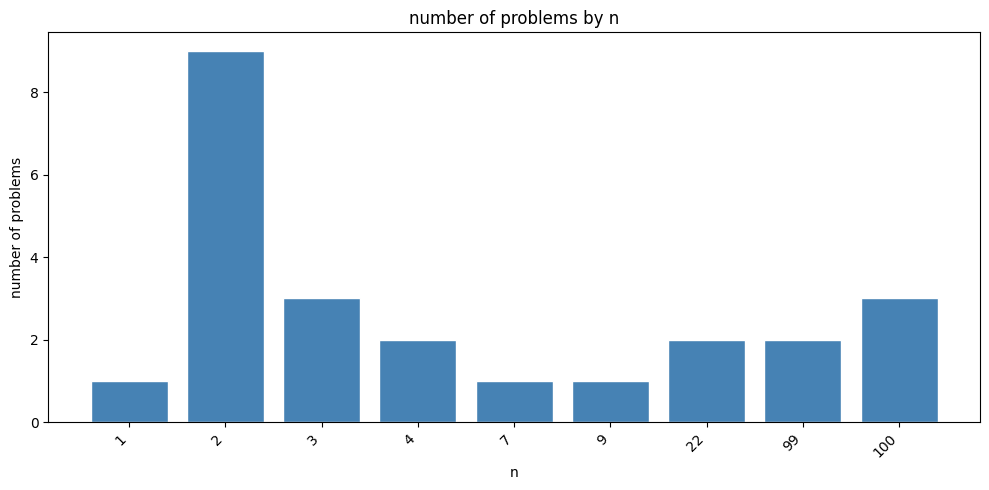

In [5]:
from collections import Counter 
import matplotlib.pyplot as plt

def count_problems_by_n(filepath: str) -> None:
    counter = Counter()
 
    with open(filepath) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split('|')
            if len(parts) < 4:
                continue
            try:
                n = int(parts[3].strip())
                counter[n] += 1
            except ValueError:
                continue  # skip header or malformed lines
 
    print(f"{'n':>6} {'num_problems':>12}")
    print("-" * 20)
    for n in sorted(counter):
        print(f"{n:>6} {counter[n]:>12}")
 
    ns = sorted(counter)
    counts = [counter[n] for n in ns]
 
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar([str(n) for n in ns], counts, color="steelblue", edgecolor="white")
    ax.set_xlabel("n")
    ax.set_ylabel("number of problems")
    ax.set_title("number of problems by n")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

count_problems_by_n("hyperparam_tuning/cutest_problem_selection_hyperparam_tuning.txt")

# Algorithm Wrappers

In [6]:
import time
import os

TIME_LIMIT_S = 600.0

def read_last_fx(filename):
    last_fx = None
    with open(filename, "r") as f:
        for line in f:
            line = line.strip()
            # Skip header and empty lines
            if not line or line.startswith("k"):
                continue
            parts = [p.strip() for p in line.split("|")]
            if len(parts) >= 3:
                try:
                    last_fx = float(parts[2])
                except ValueError:
                    pass
    return last_fx

def delete_invalid_fx_files(directory, threshold=1e20, dry_run=True):
    deleted = 0
    kept = 0
    unreadable = 0

    for filename in os.listdir(directory):
        filepath = os.path.join(directory, filename)
        if not os.path.isfile(filepath):
            continue

        fx = read_last_fx(filepath)

        forbidded_list = [6, 8, 11, 20]
        if fx is None:
            print(f"  [SKIP]    {filename} — could not read f(x)")
            unreadable += 1
        elif fx <= -threshold or fx >= threshold or (filepath.split("/")[2][0] == "h" and int(filepath.split("/")[2].split("_")[2]) in forbidded_list):
            if dry_run:
                print(f"  [DRY RUN] {filename} — f(x) = {fx:.4e}")
            else:
                print(f"  [DELETE]  {filename} — f(x) = {fx:.4e}")
                os.remove(filepath)
            deleted += 1
        else:
            kept += 1

    label = "would delete" if dry_run else "deleted"
    print(f"\nDone: {deleted} {label}, {kept} kept, {unreadable} unreadable.")

In [ ]:
def gps_expl_best_val_batch_constrained(problem_idx, num_cpus, k, k_ratio, delta, tao, n_batch_calls_limit):
    log_file_path = f"alg_logs/GPS/hyperparam_tuning_{problem_idx}_kr{k_ratio:.2f}_{delta:.2f}_{tao:.2f}_{n_batch_calls_limit}_expl_gps.txt"
    if os.path.exists(log_file_path):
        return read_last_fx(log_file_path)
    
    GPS_expl_k_fail_wrapper = BB_wrapper.BB_k_fail_wrapper(cutest_wrapper.problem_functions[problem_idx], k*torch.ones((1024, 2), dtype=torch.int16), num_cpus)
    alg = k_fail_GPS.GPS_k_fail(torch.from_numpy(cutest_wrapper.problems[problem_idx].x0), GPS_expl_k_fail_wrapper, delta, tao, prediction_software=k_fail_prediction.constant_prediction_software(k), log_file_path=log_file_path) # exploitation and utilisation are true by default

    alg.log_current(message=f"k={k}")
    
    start_time = time.time()

    while alg.n_batch_calls < n_batch_calls_limit:
        if time.time() - start_time >= TIME_LIMIT_S:
            with open("alg_logs/GPS/timeout_list.txt", "a") as f:
                f.write(f"TIME LIMIT REACHED ON: {problem_idx} | {cutest_wrapper.problems[problem_idx]} | x_k = {alg.x} | f(x) = {alg.cur_f_val}\n")
            break
        alg.step_default(random_rotate=True)
    
    return alg.cur_f_val

In [ ]:
def mbtr_expl_best_val_batch_constrained(problem_idx, num_cpus, k, k_ratio, delta, mu, eta, gamma, eps_stop, opportunistic_cpu_exploitation_manual_point_limit, preferred_model_order, n_batch_calls_limit):
    log_file_path = f"alg_logs/MBTR/hyperparam_tuning_{problem_idx}_kr{k_ratio:.2f}_{delta:.2f}_{mu:.2f}_{eta:.2f}_{gamma:.2f}_{eps_stop:.2f}_{preferred_model_order}_{opportunistic_cpu_exploitation_manual_point_limit}_{n_batch_calls_limit}_expl_mbtr.txt"
    if os.path.exists(log_file_path):
        return read_last_fx(log_file_path)

    MBTR_expl_k_fail_wrapper = BB_wrapper.BB_k_fail_wrapper(cutest_wrapper.problem_functions[problem_idx], k*torch.ones((1024, 2), dtype=torch.int16), num_cpus)

    alg = k_fail_MBTR.MBTR_k_fail(torch.from_numpy(cutest_wrapper.problems[problem_idx].x0), MBTR_expl_k_fail_wrapper, delta, mu, eta, gamma, eps_stop, prediction_software=k_fail_prediction.constant_prediction_software(k), log_file_path=log_file_path,
                                  preferred_model_order=preferred_model_order,
                                  opportunistic_cpu_exploitation_manual_point_limit=opportunistic_cpu_exploitation_manual_point_limit)
    
    alg.log_current()

    start_time = time.time()

    while alg.n_batch_calls < n_batch_calls_limit:
        if time.time() - start_time >= TIME_LIMIT_S:
            with open("alg_logs/MBTR/timeout_list.txt", "a") as f:
                f.write(f"TIME LIMIT REACHED ON: {problem_idx} | {cutest_wrapper.problems[problem_idx]} | x_k = {alg.x} | f(x) = {alg.cur_f_val}\n")
            break
        alg.step_default()
    
    return alg.cur_f_val

# Possible Values and GS

In [9]:
# general
# number of cpus will be determined for each problem manually
num_cpus_dim_brackets = [
    [4, 4], # n < 4 -> 4 cpus
    [8, 8],
    [16, 16],
    [32, 32],
    [64, 64],
    [128, 128],
]
k_ratios = [ # portion of cpus failing, will be rounded up
    0.05,
    0.1,
    0.2,
]

# GPS
gps_delta_values = [
    1.0
]
gps_tao_values = [
    0.0001,
    0.01,
    0.05,
    0.1,
    0.2,
    0.3,
    0.5,
    0.75,
    0.9,
    0.99,
]

# MBTR
mbtr_delta_values = [
    1.0,
]

mbtr_mu_values = [
    0.025,
    0.1,
    0.5,
    1.5,
]

mbtr_eta_values = [
    0.1,
    0.5,
    0.9,
]

mbtr_gamma_values = [
    0.05,
    0.25,
    0.5,
    0.9,
]

mbtr_eps_stop_values = [
    0.0,
    # 0.05,
    # 0.1,
    # 0.5,
    # 1.0,
    # 4.0,
]

mbtr_preferred_model_order_values = [
    1,
    2,
]

# MBTR function limit
mbtr_model_function_lim = lambda n: 4*n

In [10]:
from IPython.display import clear_output
from tqdm.notebook import tqdm
import math

# GPS

In [ ]:
gps_achieved_function_vals = torch.ones((cap_n_problems, len(k_ratios), len(gps_delta_values), len(gps_tao_values))) * torch.inf

pbar = tqdm(total=cap_n_problems * len(k_ratios) * len(gps_delta_values) * len(gps_tao_values))

for problem_idx in range(cap_n_problems):
    for k_ratio_idx in range(len(k_ratios)):
        for gps_delta_value_idx in range(len(gps_delta_values)):
            for gps_tao_value_idx in range(len(gps_tao_values)):
                problem_n = cutest_wrapper.problems[problem_idx].n

                num_cpus = num_cpus_dim_brackets[0][1]
                for dim, cpus in num_cpus_dim_brackets:
                    num_cpus = cpus
                    if dim > problem_n:
                        break
                
                k = math.ceil(num_cpus * k_ratios[k_ratio_idx])

                n_batch_limit = 160

                f_val = gps_expl_best_val_batch_constrained(problem_idx, num_cpus, k, k_ratios[k_ratio_idx], gps_delta_values[gps_delta_value_idx], gps_tao_values[gps_tao_value_idx], n_batch_limit)

                gps_achieved_function_vals[problem_idx, k_ratio_idx, gps_delta_value_idx, gps_tao_value_idx] = f_val

                clear_output(wait=True)
                pbar.update(1)

pbar.close()

In [12]:
torch.save(gps_achieved_function_vals, 'hyperparam_tuning/gps_achieved_function_vals.pt')

In [13]:
gps_achieved_function_vals = torch.load('hyperparam_tuning/gps_achieved_function_vals.pt')

In [14]:
gps_min_vals_combination_counter = torch.zeros((len(gps_delta_values), len(gps_tao_values)))
acc_threshold = 0.98

for problem_idx in range(cap_n_problems):
    for k_ratio_idx in range(len(k_ratios)):
        current_problem_with_k = gps_achieved_function_vals[problem_idx, k_ratio_idx]

        f_0 = cutest_wrapper.problem_functions[problem_idx](torch.from_numpy(cutest_wrapper.problems[problem_idx].x0))
        
        f_star = torch.min(current_problem_with_k)
        
        f_acc = (f_0 - current_problem_with_k) / (f_0 - f_star)
        
        gps_min_vals_combination_counter += torch.where(f_acc >= acc_threshold, 1, 0)

In [15]:
gps_min_vals_combination_counter

tensor([[45., 54., 51., 54., 60., 54., 54., 60., 57., 57.]])

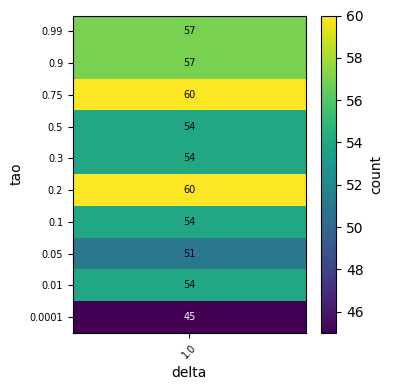

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

def plot_gps_heatmap(data_tensor, x_values, y_values, x_label='delta', y_label='tao'):
    data = data_tensor.numpy().T  # transpose so rows=tao, cols=delta
    rows, cols = data.shape
    x_labels = [str(v) for v in x_values]
    y_labels = [str(v) for v in y_values]

    if rows == 1 or cols == 1:
        fig, ax2d = plt.subplots(figsize=(4, 4))
    else:
        fig = plt.figure(figsize=(14, 6))
        x_pos, y_pos = np.meshgrid(np.arange(cols), np.arange(rows))

        ax3d = fig.add_subplot(121, projection='3d')
        ax3d.plot_surface(x_pos, y_pos, data, cmap='viridis', alpha=0.85)
        ax3d.set_xlabel(x_label)
        ax3d.set_ylabel(y_label)
        ax3d.set_zlabel('count')
        ax3d.xaxis.set_major_locator(ticker.FixedLocator(np.arange(cols)))
        ax3d.xaxis.set_major_formatter(ticker.FixedFormatter(x_labels))
        ax3d.yaxis.set_major_locator(ticker.FixedLocator(np.arange(rows)))
        ax3d.yaxis.set_major_formatter(ticker.FixedFormatter(y_labels))

        ax2d = fig.add_subplot(122)

    im = ax2d.imshow(data, cmap='viridis', aspect='auto', origin='lower')
    fig.colorbar(im, ax=ax2d, label='count')
    ax2d.set_xlabel(x_label)
    ax2d.set_ylabel(y_label)
    ax2d.xaxis.set_major_locator(ticker.FixedLocator(np.arange(cols)))
    ax2d.xaxis.set_major_formatter(ticker.FixedFormatter(x_labels))
    ax2d.yaxis.set_major_locator(ticker.FixedLocator(np.arange(rows)))
    ax2d.yaxis.set_major_formatter(ticker.FixedFormatter(y_labels))
    plt.setp(ax2d.get_xticklabels(), rotation=45, fontsize=7)
    plt.setp(ax2d.get_yticklabels(), fontsize=7)

    for i in range(rows):
        for j in range(cols):
            color = 'white' if data[i, j] < data.max() * 0.8 else 'black'
            ax2d.text(j, i, int(data[i, j]), ha='center', va='center', fontsize=7, color=color)

    plt.tight_layout()
    plt.show()


plot_gps_heatmap(gps_min_vals_combination_counter, gps_delta_values, gps_tao_values)

# MBTR

In [ ]:
mbtr_achieved_function_vals = torch.ones((cap_n_problems, len(k_ratios), len(mbtr_delta_values), len(mbtr_mu_values), len(mbtr_eta_values), len(mbtr_gamma_values), len(mbtr_eps_stop_values), len(mbtr_preferred_model_order_values))) * torch.inf

pbar = tqdm(total=cap_n_problems * len(k_ratios) * len(mbtr_delta_values) * len(mbtr_mu_values) * len(mbtr_eta_values) * len(mbtr_gamma_values) * len(mbtr_eps_stop_values) * len(mbtr_preferred_model_order_values))

for problem_idx in range(cap_n_problems):
    for k_ratio_idx in range(len(k_ratios)):
        for mbtr_delta_value_idx in range(len(mbtr_delta_values)):
            for mbtr_mu_value_idx in range(len(mbtr_mu_values)):
                for mbtr_eta_value_idx in range(len(mbtr_eta_values)):
                    for mbtr_gamma_value_idx in range(len(mbtr_gamma_values)):
                        for mbtr_eps_stop_value_idx in range(len(mbtr_eps_stop_values)):
                            for mbtr_preferred_model_order_value_idx in range(len(mbtr_preferred_model_order_values)):
                                problem_n = cutest_wrapper.problems[problem_idx].n

                                num_cpus = num_cpus_dim_brackets[0][1]
                                for dim, cpus in num_cpus_dim_brackets:
                                    num_cpus = cpus
                                    if dim > problem_n:
                                        break
                                
                                k = math.ceil(num_cpus * k_ratios[k_ratio_idx])

                                n_batch_limit = 160

                                f_val = mbtr_expl_best_val_batch_constrained(problem_idx, num_cpus, k, k_ratios[k_ratio_idx], mbtr_delta_values[mbtr_delta_value_idx], mbtr_mu_values[mbtr_mu_value_idx], mbtr_eta_values[mbtr_eta_value_idx], mbtr_gamma_values[mbtr_gamma_value_idx], mbtr_eps_stop_values[mbtr_eps_stop_value_idx], mbtr_model_function_lim(problem_n), mbtr_preferred_model_order_values[mbtr_preferred_model_order_value_idx], n_batch_limit)

                                mbtr_achieved_function_vals[problem_idx, k_ratio_idx, mbtr_delta_value_idx, mbtr_mu_value_idx, mbtr_eta_value_idx, mbtr_gamma_value_idx, mbtr_eps_stop_value_idx, mbtr_preferred_model_order_value_idx] = f_val

                                clear_output(wait=True)
                                pbar.update(1)

pbar.close()

In [20]:
torch.save(mbtr_achieved_function_vals, 'hyperparam_tuning/mbtr_achieved_function_vals.pt')

In [21]:
mbtr_achieved_function_vals = torch.load('hyperparam_tuning/mbtr_achieved_function_vals.pt')

In [23]:
mbtr_min_vals_combination_counter = torch.zeros((len(mbtr_delta_values), len(mbtr_mu_values), len(mbtr_eta_values), len(mbtr_gamma_values), len(mbtr_eps_stop_values), len(mbtr_preferred_model_order_values)))
acc_threshold = 0.98

for problem_idx in range(cap_n_problems):
    for k_ratio_idx in range(len(k_ratios)):
        current_problem_with_k = mbtr_achieved_function_vals[problem_idx, k_ratio_idx]

        f_0 = cutest_wrapper.problem_functions[problem_idx](torch.from_numpy(cutest_wrapper.problems[problem_idx].x0))
        
        f_star = torch.min(current_problem_with_k)
        
        f_acc = (f_0 - current_problem_with_k) / (f_0 - f_star)
        
        mbtr_min_vals_combination_counter += torch.where(f_acc >= acc_threshold, 1, 0)

In [24]:
mbtr_min_vals_combination_counter.shape

torch.Size([1, 4, 3, 4, 1, 2])

In [25]:
import itertools
import numpy as np
from rich.console import Console
from rich.table import Table
from rich import box

ALL_LISTS = [
    ("delta",       mbtr_delta_values),
    ("mu",          mbtr_mu_values),
    ("eta",         mbtr_eta_values),
    ("gamma",       mbtr_gamma_values),
    ("eps_stop",    mbtr_eps_stop_values),
    ("model_order", mbtr_preferred_model_order_values),
]

def value_to_rgb(val, t_min, t_max):
    ratio = 0.5 if t_max == t_min else (val - t_min) / (t_max - t_min)
    if ratio < 0.5:
        r, g = 255, int(255 * ratio * 2)
    else:
        r, g = int(255 * (1 - ratio) * 2), 255
    return r, g, 0


def write_rtf(sections, named_lists, t_min, t_max, filename):
    """sections: list of (title, rows)"""
    col_names = ["#"] + [name for name, _ in named_lists] + ["f(x)"]
    n_cols = len(col_names)
    col_width = 1500

    colors = [(0, 0, 0)]
    color_map = {}
    for _, rows in sections:
        for _, _, _, val in rows:
            rgb = value_to_rgb(val, t_min, t_max)
            if rgb not in color_map:
                color_map[rgb] = len(colors) + 1
                colors.append(rgb)

    color_table = "{\\colortbl ;" + "".join(
        f"\\red{r}\\green{g}\\blue{b};" for r, g, b in colors
    ) + "}"

    def make_row(cells, bold=False, fx_color_idx=None):
        row = "\\trowd\\trgaph108\\trleft-108"
        for i in range(n_cols):
            row += f"\\cellx{col_width * (i + 1)}"
        row += "\n"
        for i, cell in enumerate(cells):
            ci = fx_color_idx if (fx_color_idx and i == n_cols - 1) else 1
            b = "\\b " if bold else ""
            row += f"\\intbl {b}\\cf{ci} {cell}\\cell\n"
        row += "\\row\n"
        return row

    rtf = "{\\rtf1\\ansi\n" + color_table + "\n\\f0\\fs20\n"

    for section_title, rows in sections:
        rtf += f"\\pard\\b {section_title}\\b0\\par\n"
        rtf += make_row(col_names, bold=True)
        for row_idx, idx, labels, val in rows:
            ci = color_map[value_to_rgb(val, t_min, t_max)]
            cells = [str(row_idx)] + labels + [f"{val:.4f}"]
            rtf += make_row(cells, fx_color_idx=ci)
        rtf += "\\pard\\par\n"

    rtf += "}"
    with open(filename, "w") as f:
        f.write(rtf)
    print(f"RTF written to {filename}")


def tensor_table(tensor, named_lists, top_n=5,
                 fixed_column=None, fixed_column_vals=None,
                 rtf_file=None):
    console = Console()
    lists = [lst for _, lst in named_lists]
    col_names = [name for name, _ in named_lists]

    t = np.array(tensor)
    t_min, t_max = float(t.min()), float(t.max())

    def rich_color(val):
        r, g, _ = value_to_rgb(val, t_min, t_max)
        return f"#{r:02x}{g:02x}00"

    # Collect all rows
    all_rows = []
    for row_idx, idx in enumerate(itertools.product(*[range(len(lst)) for lst in lists])):
        val = float(t[idx])
        labels = [str(lists[dim][i]) for dim, i in enumerate(idx)]
        all_rows.append((row_idx, idx, labels, val))

    def make_rich_table(title, rows, style):
        tbl = Table(title=title, box=box.SIMPLE_HEAVY, show_header=True, header_style=style)
        tbl.add_column("#", justify="right", style="dim")
        for name in col_names:
            tbl.add_column(name, justify="center")
        tbl.add_column("f(x)", justify="right")
        for row_idx, idx, labels, val in rows:
            color = rich_color(val)
            tbl.add_row(str(row_idx), *labels, f"[{color}]{val:.4f}[/{color}]")
        return tbl

    # --- Top N tables (one per fixed column value) ---
    rtf_sections = []

    if fixed_column is not None and fixed_column_vals is not None:
        col_idx = col_names.index(fixed_column)
        for fixed_val in fixed_column_vals:
            filtered = [
                r for r in all_rows
                if r[2][col_idx] == str(fixed_val)
            ]
            top_rows = sorted(filtered, key=lambda r: r[3], reverse=True)[:top_n]
            title = f"Top {top_n} highest f(x)  |  {fixed_column} = {fixed_val}"
            console.print(make_rich_table(title, top_rows, "bold white"))
            console.print()
            rtf_sections.append((title, top_rows))
    else:
        top_rows = sorted(all_rows, key=lambda r: r[3], reverse=True)[:top_n]
        title = f"Top {top_n} highest f(x)"
        console.print(make_rich_table(title, top_rows, "bold white"))
        console.print()
        rtf_sections.append((title, top_rows))

    # --- Full table ---
    full_table = Table(box=box.ROUNDED, show_header=True, header_style="bold cyan")
    full_table.add_column("#", justify="right", style="dim")
    for name in col_names:
        full_table.add_column(name, justify="center")
    full_table.add_column("f(x)", justify="right")
    for row_idx, idx, labels, val in all_rows:
        color = rich_color(val)
        full_table.add_row(str(row_idx), *labels, f"[{color}]{val:.4f}[/{color}]")
    console.print(full_table)

    # --- RTF export ---
    if rtf_file is not None:
        write_rtf(rtf_sections, named_lists, t_min, t_max, rtf_file)


In [26]:
tensor_table(mbtr_min_vals_combination_counter, ALL_LISTS, top_n=40, fixed_column="model_order", fixed_column_vals=[1, 2], rtf_file="hyperparam_tuning/mbtr_restults.rtf")

/var/folders/t5/xn7v81p12c5cqbknr4g3qm1h0000gn/T/ipykernel_41834/2235322231.py:80: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  t = np.array(tensor)


                Top 40 highest f(x)  |  model_order = 1                
                                                                       
   #   delta    mu     eta   gamma   eps_stop   model_order      f(x)  
 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 
  76    1.0     1.5    0.1    0.5      0.0           1        51.0000  
  48    1.0     0.5    0.1   0.05      0.0           1        48.0000  
  50    1.0     0.5    0.1   0.25      0.0           1        48.0000  
  52    1.0     0.5    0.1    0.5      0.0           1        48.0000  
  56    1.0     0.5    0.5   0.05      0.0           1        48.0000  
  72    1.0     1.5    0.1   0.05      0.0           1        48.0000  
  74    1.0     1.5    0.1   0.25      0.0           1        48.0000  
  78    1.0     1.5    0.1    0.9      0.0           1        48.0000  
  80    1.0     1.5    0.5   0.05      0.0           1        48.0000  
  84    1.0     1.5    0.5    0.5      0.0           1        48.0000  
  26    1.0     0.1    0.1   0.25      0.0           1        45.0000  
  28    1.0     0.1    0.1    0.5      0.0           1        45.0000  
  30    1.0     0.1    0.1    0.9      0.0           1        45.0000  
  36    1.0     0.1    0.5    0.5      0.0           1        45.0000  
  44    1.0     0.1    0.9    0.5      0.0           1        45.0000  
  54    1.0     0.5    0.1    0.9      0.0           1        45.0000  
  58    1.0     0.5    0.5   0.25      0.0           1        45.0000  
  60    1.0     0.5    0.5    0.5      0.0           1        45.0000  
  66    1.0     0.5    0.9   0.25      0.0           1        45.0000  
  68    1.0     0.5    0.9    0.5      0.0           1        45.0000  
  82    1.0     1.5    0.5   0.25      0.0           1        45.0000  
  86    1.0     1.5    0.5    0.9      0.0           1        45.0000  
  90    1.0     1.5    0.9   0.25      0.0           1        45.0000  
  92    1.0     1.5    0.9    0.5      0.0           1        45.0000  
  24    1.0     0.1    0.1   0.05      0.0           1        42.0000  
  32    1.0     0.1    0.5   0.05      0.0           1        42.0000  
  34    1.0     0.1    0.5   0.25      0.0           1        42.0000  
  38    1.0     0.1    0.5    0.9      0.0           1        42.0000  
  42    1.0     0.1    0.9   0.25      0.0           1        42.0000  
  62    1.0     0.5    0.5    0.9      0.0           1        42.0000  
   2    1.0    0.025   0.1   0.25      0.0           1        39.0000  
   0    1.0    0.025   0.1   0.05      0.0           1        36.0000  
   4    1.0    0.025   0.1    0.5      0.0           1        36.0000  
   6    1.0    0.025   0.1    0.9      0.0           1        36.0000  
  10    1.0    0.025   0.5   0.25      0.0           1        36.0000  
  12    1.0    0.025   0.5    0.5      0.0           1        36.0000  
  18    1.0    0.025   0.9   0.25      0.0           1        36.0000  
  20    1.0    0.025   0.9    0.5      0.0           1        36.0000  
  46    1.0     0.1    0.9    0.9      0.0           1        36.0000  
  64    1.0     0.5    0.9   0.05      0.0           1        36.0000

                Top 40 highest f(x)  |  model_order = 2                
                                                                       
   #   delta    mu     eta   gamma   eps_stop   model_order      f(x)  
 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 
  51    1.0     0.5    0.1   0.25      0.0           2        60.0000  
  75    1.0     1.5    0.1   0.25      0.0           2        60.0000  
  53    1.0     0.5    0.1    0.5      0.0           2        57.0000  
  73    1.0     1.5    0.1   0.05      0.0           2        57.0000  
  27    1.0     0.1    0.1   0.25      0.0           2        54.0000  
  49    1.0     0.5    0.1   0.05      0.0           2        54.0000  
  77    1.0     1.5    0.1    0.5      0.0           2        54.0000  
  25    1.0     0.1    0.1   0.05      0.0           2        51.0000  
  29    1.0     0.1    0.1    0.5      0.0           2        51.0000  
   3    1.0    0.025   0.1   0.25      0.0           2        48.0000  
   5    1.0    0.025   0.1    0.5      0.0           2        45.0000  
  55    1.0     0.5    0.1    0.9      0.0           2        45.0000  
  57    1.0     0.5    0.5   0.05      0.0           2        45.0000  
  59    1.0     0.5    0.5   0.25      0.0           2        45.0000  
  63    1.0     0.5    0.5    0.9      0.0           2        45.0000  
  79    1.0     1.5    0.1    0.9      0.0           2        45.0000  
  81    1.0     1.5    0.5   0.05      0.0           2        45.0000  
  83    1.0     1.5    0.5   0.25      0.0           2        45.0000  
  87    1.0     1.5    0.5    0.9      0.0           2        45.0000  
   1    1.0    0.025   0.1   0.05      0.0           2        42.0000  
  31    1.0     0.1    0.1    0.9      0.0           2        42.0000  
  35    1.0     0.1    0.5   0.25      0.0           2        42.0000  
  39    1.0     0.1    0.5    0.9      0.0           2        42.0000  
  61    1.0     0.5    0.5    0.5      0.0           2        42.0000  
  85    1.0     1.5    0.5    0.5      0.0           2        42.0000  
  33    1.0     0.1    0.5   0.05      0.0           2        39.0000  
  37    1.0     0.1    0.5    0.5      0.0           2        39.0000  
  67    1.0     0.5    0.9   0.25      0.0           2        39.0000  
  69    1.0     0.5    0.9    0.5      0.0           2        39.0000  
  91    1.0     1.5    0.9   0.25      0.0           2        39.0000  
  93    1.0     1.5    0.9    0.5      0.0           2        39.0000  
   7    1.0    0.025   0.1    0.9      0.0           2        36.0000  
  11    1.0    0.025   0.5   0.25      0.0           2        36.0000  
  15    1.0    0.025   0.5    0.9      0.0           2        36.0000  
  43    1.0     0.1    0.9   0.25      0.0           2        36.0000  
  45    1.0     0.1    0.9    0.5      0.0           2        36.0000  
  65    1.0     0.5    0.9   0.05      0.0           2        36.0000  
  71    1.0     0.5    0.9    0.9      0.0           2        36.0000  
  89    1.0     1.5    0.9   0.05      0.0           2        36.0000  
  95    1.0     1.5    0.9    0.9      0.0           2        36.0000

╭────┬───────┬───────┬─────┬───────┬──────────┬─────────────┬─────────╮
│  # │ delta │  mu   │ eta │ gamma │ eps_stop │ model_order │    f(x) │
├────┼───────┼───────┼─────┼───────┼──────────┼─────────────┼─────────┤
│  0 │  1.0  │ 0.025 │ 0.1 │ 0.05  │   0.0    │      1      │ 36.0000 │
│  1 │  1.0  │ 0.025 │ 0.1 │ 0.05  │   0.0    │      2      │ 42.0000 │
│  2 │  1.0  │ 0.025 │ 0.1 │ 0.25  │   0.0    │      1      │ 39.0000 │
│  3 │  1.0  │ 0.025 │ 0.1 │ 0.25  │   0.0    │      2      │ 48.0000 │
│  4 │  1.0  │ 0.025 │ 0.1 │  0.5  │   0.0    │      1      │ 36.0000 │
│  5 │  1.0  │ 0.025 │ 0.1 │  0.5  │   0.0    │      2      │ 45.0000 │
│  6 │  1.0  │ 0.025 │ 0.1 │  0.9  │   0.0    │      1      │ 36.0000 │
│  7 │  1.0  │ 0.025 │ 0.1 │  0.9  │   0.0    │      2      │ 36.0000 │
│  8 │  1.0  │ 0.025 │ 0.5 │ 0.05  │   0.0    │      1      │ 33.0000 │
│  9 │  1.0  │ 0.025 │ 0.5 │ 0.05  │   0.0    │      2      │ 30.0000 │
│ 10 │  1.0  │ 0.025 │ 0.5 │ 0.25  │   0.0    │      1      │ 36.0000 │
│ 11 │  1.0  │ 0.025 │ 0.5 │ 0.25  │   0.0    │      2      │ 36.0000 │
│ 12 │  1.0  │ 0.025 │ 0.5 │  0.5  │   0.0    │      1      │ 36.0000 │
│ 13 │  1.0  │ 0.025 │ 0.5 │  0.5  │   0.0    │      2      │ 33.0000 │
│ 14 │  1.0  │ 0.025 │ 0.5 │  0.9  │   0.0    │      1      │ 33.0000 │
│ 15 │  1.0  │ 0.025 │ 0.5 │  0.9  │   0.0    │      2      │ 36.0000 │
│ 16 │  1.0  │ 0.025 │ 0.9 │ 0.05  │   0.0    │      1      │ 27.0000 │
│ 17 │  1.0  │ 0.025 │ 0.9 │ 0.05  │   0.0    │      2      │ 24.0000 │
│ 18 │  1.0  │ 0.025 │ 0.9 │ 0.25  │   0.0    │      1      │ 36.0000 │
│ 19 │  1.0  │ 0.025 │ 0.9 │ 0.25  │   0.0    │      2      │ 30.0000 │
│ 20 │  1.0  │ 0.025 │ 0.9 │  0.5  │   0.0    │      1      │ 36.0000 │
│ 21 │  1.0  │ 0.025 │ 0.9 │  0.5  │   0.0    │      2      │ 30.0000 │
│ 22 │  1.0  │ 0.025 │ 0.9 │  0.9  │   0.0    │      1      │ 27.0000 │
│ 23 │  1.0  │ 0.025 │ 0.9 │  0.9  │   0.0    │      2      │ 27.0000 │
│ 24 │  1.0  │  0.1  │ 0.1 │ 0.05  │   0.0    │      1      │ 42.0000 │
│ 25 │  1.0  │  0.1  │ 0.1 │ 0.05  │   0.0    │      2      │ 51.0000 │
│ 26 │  1.0  │  0.1  │ 0.1 │ 0.25  │   0.0    │      1      │ 45.0000 │
│ 27 │  1.0  │  0.1  │ 0.1 │ 0.25  │   0.0    │      2      │ 54.0000 │
│ 28 │  1.0  │  0.1  │ 0.1 │  0.5  │   0.0    │      1      │ 45.0000 │
│ 29 │  1.0  │  0.1  │ 0.1 │  0.5  │   0.0    │      2      │ 51.0000 │
│ 30 │  1.0  │  0.1  │ 0.1 │  0.9  │   0.0    │      1      │ 45.0000 │
│ 31 │  1.0  │  0.1  │ 0.1 │  0.9  │   0.0    │      2      │ 42.0000 │
│ 32 │  1.0  │  0.1  │ 0.5 │ 0.05  │   0.0    │      1      │ 42.0000 │
│ 33 │  1.0  │  0.1  │ 0.5 │ 0.05  │   0.0    │      2      │ 39.0000 │
│ 34 │  1.0  │  0.1  │ 0.5 │ 0.25  │   0.0    │      1      │ 42.0000 │
│ 35 │  1.0  │  0.1  │ 0.5 │ 0.25  │   0.0    │      2      │ 42.0000 │
│ 36 │  1.0  │  0.1  │ 0.5 │  0.5  │   0.0    │      1      │ 45.0000 │
│ 37 │  1.0  │  0.1  │ 0.5 │  0.5  │   0.0    │      2      │ 39.0000 │
│ 38 │  1.0  │  0.1  │ 0.5 │  0.9  │   0.0    │      1      │ 42.0000 │
│ 39 │  1.0  │  0.1  │ 0.5 │  0.9  │   0.0    │      2      │ 42.0000 │
│ 40 │  1.0  │  0.1  │ 0.9 │ 0.05  │   0.0    │      1      │ 30.0000 │
│ 41 │  1.0  │  0.1  │ 0.9 │ 0.05  │   0.0    │      2      │ 30.0000 │
│ 42 │  1.0  │  0.1  │ 0.9 │ 0.25  │   0.0    │      1      │ 42.0000 │
│ 43 │  1.0  │  0.1  │ 0.9 │ 0.25  │   0.0    │      2      │ 36.0000 │
│ 44 │  1.0  │  0.1  │ 0.9 │  0.5  │   0.0    │      1      │ 45.0000 │
│ 45 │  1.0  │  0.1  │ 0.9 │  0.5  │   0.0    │      2      │ 36.0000 │
│ 46 │  1.0  │  0.1  │ 0.9 │  0.9  │   0.0    │      1      │ 36.0000 │
│ 47 │  1.0  │  0.1  │ 0.9 │  0.9  │   0.0    │      2      │ 33.0000 │
│ 48 │  1.0  │  0.5  │ 0.1 │ 0.05  │   0.0    │      1      │ 48.0000 │
│ 49 │  1.0  │  0.5  │ 0.1 │ 0.05  │   0.0    │      2      │ 54.0000 │
│ 50 │  1.0  │  0.5  │ 0.1 │ 0.25  │   0.0    │      1      │ 48.0000 │
│ 51 │  1.0  │  0.5  │ 0.1 │ 0.25  │   0.0    │      2      │ 60.0000 │
│ 52 │  1.0  │  0.5  │ 0.1 │  0.5  │   0

RTF written to hyperparam_tuning/mbtr_restults.rtf


In [37]:
abnormal_p_names = []

with open("alg_logs/abnormalities.txt", "r") as _f:
    for line in _f:
        p_name = line.split()[0]
        if not p_name in abnormal_p_names:
            abnormal_p_names.append(p_name)

for n in abnormal_p_names:
    print(n)

BOX3
LANCZOS3LS
LANCZOS1LS
DANWOODLS
CHWIRUT2LS
MGH10LS
GAUSS1LS
BA-L1LS
GAUSS3LS
NELSONLS
DENSCHND
DENSCHNE
EXPFIT
GAUSS2LS
CHWIRUT1LS
HIMMELBB


In [38]:
len(abnormal_p_names)

16